#### 读取EXCEL

In [ ]:
import pandas as pd
excel_file = 'data.xlsx'
sheet_name = 'Doc1'
output_path = 'Doc1.csv'
df = pd.read_excel(excel_file, sheet_name=sheet_name)
df.to_csv(output_path, index=False, encoding='utf-8-sig')

#### vedio转frame

In [ ]:
import os
import cv2
import csv
from datetime import timedelta
from concurrent.futures import ThreadPoolExecutor
from tqdm import tqdm

# ================== 中英部位对照表 ==================
PART_TRANSLATION = {
    "回肠末端": "terminalIleum",
    "盲肠": "cecum",
    "升结肠": "ascendingColon",
    "结肠肝曲": "hepaticFlexure",
    "横结肠": "transverseColon",
    "结肠脾曲": "splenicFlexure",
    "降结肠": "descendingColon",
    "乙状结肠": "sigmoidColon",
    "直肠": "rectum",
    "肛管": "analCanal",
}


# ================== CSV解析模块增强版 ==================
def parse_time_segment(segment):
    """支持单点时间解析（如0:25-0:25）"""
    try:
        m, s = segment.strip().split(":")
        total_sec = int(m) * 60 + int(s)
        return total_sec
    except:
        return 0


def load_csv_data(csv_path):
    """解析CSV文件，返回结构：{视频号: {部位: [时间区间]} }"""
    csv_data = {}
    with open(csv_path, "r", encoding="utf-8") as f:
        reader = csv.reader(f)
        for row_idx, row in enumerate(reader, 1):
            if len(row) < 11:
                print(f"警告：第{row_idx}行数据不完整，已跳过")
                continue

            video_id = row[0]
            csv_data[video_id] = {}

            # 解析每个部位的时间区间
            for i in range(1, 11):
                part_name = list(PART_TRANSLATION.keys())[i - 1]
                time_str = row[i].replace(" ", "").replace("/", ",")
                time_ranges = []

                for interval in time_str.split(","):
                    if "-" not in interval:
                        if ":" in interval:  # 处理单点时间
                            point = parse_time_segment(interval)
                            time_ranges.append((point, point + 1))
                        continue

                    start_str, end_str = interval.split("-")
                    start = parse_time_segment(start_str)
                    end = parse_time_segment(end_str)

                    end += 1  # 单点时间扩展为1秒区间
                    time_ranges.append((start, end))

                if time_ranges:
                    csv_data[video_id][PART_TRANSLATION[part_name]] = time_ranges
    return csv_data


# ================== 视频处理模块增强版 ==================
def extract_key_frames(video_path, csv_info, output_dir):
    """处理单个视频文件，支持多线程"""
    cap = cv2.VideoCapture(video_path)
    if not cap.isOpened():
        print(f"无法打开视频文件: {video_path}")
        return

    # 获取精确视频信息
    fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    duration = total_frames / fps
    video_id = os.path.splitext(os.path.basename(video_path))[0]

    if video_id not in csv_info:
        print(f"CSV中未找到视频号: {video_id}")
        return

    # 使用tqdm进度条
    with tqdm(total=int(duration), desc=f"处理 {video_id}", unit="秒") as pbar:
        for second in range(int(duration)):
            # 精确计算中间帧
            target_frame = int(round(second * fps + fps / 2))
            if target_frame >= total_frames:
                break

            cap.set(cv2.CAP_PROP_POS_FRAMES, target_frame)
            ret, frame = cap.read()
            if not ret:
                continue

            # 查找匹配的部位标签
            matched_parts = []
            for part_name, ranges in csv_info[video_id].items():
                for start, end in ranges:
                    if start <= second < end:  # 修正时间区间判断
                        matched_parts.append(part_name)
                        break

            # 生成符合医学命名规范的文件名
            for part in matched_parts:
                filename = f"{video_id}_{part}_{second}s.jpg"
                output_path = os.path.join(output_dir, filename)
                cv2.imwrite(output_path, frame)

            pbar.update(1)

    cap.release()


# ================== 主程序增强版 ==================
if __name__ == "__main__":
    # 配置路径
    VIDEO_FOLDER = "D:/DATA/vediotime_processed"
    CSV_FILE = "data/doc1.csv"
    OUTPUT_DIR = "D:/DATA/image"

    # 创建输出目录（增强权限处理）
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    if not os.access(OUTPUT_DIR, os.W_OK):
        raise PermissionError(f"无写入权限: {OUTPUT_DIR}")

    # 加载CSV数据（增加异常处理）
    try:
        csv_data = load_csv_data(CSV_FILE)
    except Exception as e:
        print(f"CSV解析失败: {str(e)}")
        exit(1)

    # 获取视频文件列表
    video_files = [
        os.path.join(VIDEO_FOLDER, f) for f in os.listdir(VIDEO_FOLDER) if f.lower().endswith((".mp4", ".avi", ".mov"))
    ]

    # 多线程处理（参考网页4）
    with ThreadPoolExecutor(max_workers=4) as executor:
        futures = []
        for video_path in video_files:
            futures.append(executor.submit(extract_key_frames, video_path, csv_data, OUTPUT_DIR))

        # 显示进度
        for future in tqdm(futures, desc="总进度"):
            future.result()

    print(f"处理完成！共处理{len(video_files)}个视频，输出目录: {OUTPUT_DIR}")


### videocrop

计算裁剪参数

In [ ]:
import cv2
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

def detect_bounds(img_path):
    """整合预处理与边界检测的核心功能[3,5](@ref)"""
    img = cv2.imread(img_path)
    if img is None:
        return None
    
    # 灰度化与自适应阈值
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    vertical_sum = np.sum(gray, axis=0)  # 输出形状 (width,)
    horizontal_sum = np.sum(gray[:, 300:1000], axis=1)  # 输出形状 (width,)
    x_coords = np.arange(len(vertical_sum))  # 生成x坐标序列

    # 左边界条件：200≤x≤600且像素值<2000的最大x坐标
    left_cond = (x_coords >= 200) & (x_coords <= 600) & (vertical_sum < 2000)
    left_candidates = np.where(left_cond)[0]
    left = left_candidates.max() if left_candidates.size > 0 else 200  # 默认值保护

    # 右边界条件：x>1000且像素值<2000的最小x坐标
    right_cond = (x_coords > 1000) & (vertical_sum < 5000)
    right_candidates = np.where(right_cond)[0]
    right = right_candidates.min() if right_candidates.size > 0 else 1280  # 默认值保护

    # 条件：y < 100 且像素和 < 1000 的最大y坐标
    upper_zone = horizontal_sum[:100]  # 取前100行
    upper_candidates = np.where(upper_zone < 4000)[0]
    top = upper_candidates.max() if upper_candidates.size > 0 else 100
    lower_zone = horizontal_sum[-100:]  # 取最后100行
    lower_candidates = np.where(lower_zone < 2000)[0]
    bottom = (gray.shape[0] - 100) + lower_candidates.min() if lower_candidates.size > 0 else gray.shape[0]

    # print(left,right)
    aa = 0
    return {
        'x': max(0, left - aa),
        'y': max(0, top - aa),
        'width': min(gray.shape[1], right - left + aa*2),
        'height': min(gray.shape[0], bottom - top + aa*2)
    }

def process_video(video_dir, sample_size=5):
    """视频处理主流程[2](@ref)"""
    params = []
    for frame in os.listdir(video_dir)[:sample_size]:
        result = detect_bounds(os.path.join(video_dir, frame))
        if result and result['width'] > 0 and result['height'] > 0:
            params.append(result)
    
    # 取中位数作为最终参数
    return {
        'x': int(np.median([p['x'] for p in params])),
        'y': int(np.median([p['y'] for p in params])),
        'width': int(np.median([p['width'] for p in params])),
        'height': int(np.median([p['height'] for p in params]))
    } if params else None

# 批量处理并保存结果
results = []
for video in os.listdir('D:/DATA/img_select'):
    res = process_video(os.path.join('D:/DATA/img_select', video))
    if res:
        results.append({
            'video_name': video.split('_')[0],
            'x': res['x'],
            'y': res['y'],
            'width': res['width'],
            'height': res['height']
        })

pd.DataFrame(results).to_csv('simple_crop_params.csv', index=False)

裁剪

In [ ]:
import pandas as pd
import os
import subprocess

# 设备型号坐标映射
DEVICE_CROP = {"CF-HQ290I": "crop=840:720:440:0", "CF-H290I": "crop=790:680:460:20", "CF-Q260AI": "crop=790:680:460:20"}

# 读取CSV映射表
df = pd.read_csv("data/doc1.csv", encoding="utf-8")
video_mapping = df.set_index("视频号")["设备型号"].to_dict()

# 路径配置
input_dir = "D:/DATA/vediotime"
output_dir = "D:/DATA/vediotime_processed"
os.makedirs(output_dir, exist_ok=True)

# 高性能编码参数（平衡质量与速度）
ENCODE_PARAMS = [
    "-c:v libx264",
    "-preset slower",  # 比veryslow节省30%时间，质量损失可忽略
    "-crf 18",
    "-x264-params ref=5:bframes=5",
    "-profile:v high",
    "-pix_fmt yuv420p",  # 改为8bit兼容格式
    "-an",
    "-movflags +faststart",
]

for filename in os.listdir(input_dir):
    if "_cut.mp4" in filename:

        # 提取视频号
        vid = filename.split("_cut")[0]

        # 匹配设备参数
        vid = int(vid)
        if vid in video_mapping:

            device = video_mapping[vid]
            crop_filter = DEVICE_CROP.get(device)
            if crop_filter:
                # 构建FFmpeg命令
                print(os.path.join(input_dir, filename))
                cmd = [
                    "ffmpeg",
                    "-i",
                    os.path.join(input_dir, filename),
                    "-vf",
                    crop_filter,
                    "-c:v",
                    "libx264",
                    "-preset",
                    "slower",
                    "-crf",
                    "18",
                    "-profile:v",
                    "high",
                    "-pix_fmt",
                    "yuv420p",
                    "-an",
                    "-movflags",
                    "+faststart",
                    os.path.join(output_dir, f"{vid}_processed.mp4"),
                ]
                print(cmd)
                # 执行命令并显示进度
                try:
                    process = subprocess.run(cmd, stderr=subprocess.PIPE, universal_newlines=True)  # 捕获错误流
                    print(f"成功处理：{filename}")
                except Exception as e:
                    print(f"FFmpeg错误输出:\n{process.stderr}")  # 打印详细错误


### 一致性分析

数据准备

In [ ]:
import pandas as pd
import numpy as np
from datetime import datetime
from sklearn.metrics import cohen_kappa_score


def parse_time_segments(time_str):
    """处理可能包含多个时间段的情况(用/分隔)"""
    segments = []
    # 拆分多个时间段[3,5](@ref)
    for part in time_str.split('/'):
        if '-' not in part: continue  # 跳过无效格式
        try:
            start_str, end_str = part.strip().split('-')
            # 处理缺失前导零的情况(如0:09)[5](@ref)
            start_str = start_str.zfill(5) if len(start_str) <5 else start_str
            end_str = end_str.zfill(5) if len(end_str) <5 else end_str
            
            # 转换为秒数[1](@ref)
            start = datetime.strptime(start_str, "%M:%S").minute*60 + datetime.strptime(start_str, "%M:%S").second
            end = datetime.strptime(end_str, "%M:%S").minute*60 + datetime.strptime(end_str, "%M:%S").second
            segments.append( (start, end) )
        except:
            pass  # 忽略无法解析的片段
    return segments


def build_label_matrix(row, doctor_prefix):
    """构建带有多时间段的标签矩阵"""
    label_matrix = {}
    structures = ['回肠末端', '盲肠', '升结肠', '结肠肝曲', '横结肠',
                 '结肠脾曲', '降结肠', '乙状结肠', '直肠', '肛管']
    
    for struct in structures:
        # 获取该医生的所有时间段[3](@ref)
        time_ranges = parse_time_segments(row[f"{doctor_prefix}{struct}"])
        
        # 标记每个时间段内的秒数
        for (start, end) in time_ranges:
            for t in range(start, end+1):
                label_matrix[t] = struct  # 相同时间点会被最后处理的覆盖
    
    return label_matrix

# ======================
# 主处理流程
# ======================
# 读取原始数据（示例）
doc1_df = pd.read_csv('data/doc1.csv')
doc2_df = pd.read_csv('data/doc2.csv')

# 合并数据集
merged_data = []
for _, row in doc1_df.iterrows():
    video_id = row['视频号']
    # 构建两位医生的标签矩阵[8](@ref)
    doctorA = build_label_matrix(row, '')
    doctorB_row = doc2_df[doc2_df['视频号'] == video_id].iloc[0]
    doctorB = build_label_matrix(doctorB_row, '')
    
    # 获取共同时间轴
    max_time = max(doctorA.keys() | doctorB.keys(), default=0)
    for t in range(max_time+1):
        merged_data.append({
            '视频号': video_id,
            '时间点': t,
            '医生A': doctorA.get(t, '未标注'),
            '医生B': doctorB.get(t, '未标注')
        })

# 转换为DataFrame
merged_df = pd.DataFrame(merged_data)
merged_df.to_csv('m.csv')

混淆矩阵

In [ ]:

# 定义翻译字典
import pandas as pd
from sklearn.metrics import cohen_kappa_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
PART_TRANSLATION = {
    "回肠末端": "Terminal_Ileum",
    "盲肠": "Cecum",
    "升结肠": "Ascending_Colon",
    "结肠肝曲": "Hepatic_Flexure",
    "横结肠": "Transverse_Colon",
    "结肠脾曲": "Splenic_Flexure",
    "降结肠": "Descending_Colon",
    "乙状结肠": "Sigmoid_Colon",
    "直肠": "Rectum",
    "肛管": "Anal_Canal"
}

# 读取数据
df = pd.read_csv(r"D:\project\Coloseg\m.csv")

# 新版合并方法（替换append）
combined_series = pd.concat([df['医生A'], df['医生B']])
all_labels = combined_series.unique().tolist()

# 自定义解剖部位顺序（示例）
DEFAULT_ORDER = ['回肠末端', '盲肠', '升结肠', '结肠肝曲', '横结肠',
                 '结肠脾曲', '降结肠', '乙状结肠', '直肠', '肛管']  # 按实际需求补充完整顺序
sorted_labels = [x for x in DEFAULT_ORDER if x in all_labels]

# 计算混淆矩阵
cm = confusion_matrix(df['医生A'], df['医生B'], labels=sorted_labels)

# 生成英文标签
en_labels = [PART_TRANSLATION[label] for label in sorted_labels]

plt.figure(figsize=(10, 8))  # 增大画布尺寸[7,8](@ref)
sns.set(font_scale=1.2)  # 全局字体缩放[6](@ref)

heatmap = sns.heatmap(
    cm, 
    annot=True, 
    fmt='d',
    annot_kws={'size': 14},  # 调整注释数字大小[6](@ref)
    xticklabels=en_labels,
    yticklabels=en_labels,
    cmap='Blues',
    linewidths=0.5  # 单元格边框粗细
)

# 坐标轴标签字体设置
heatmap.set_xlabel('Doctor B', fontsize=16, fontweight='bold')  # X轴标签[3,4](@ref)
heatmap.set_ylabel('Doctor A', fontsize=16, fontweight='bold')  # Y轴标签[3,4](@ref)

# 标题设置
plt.title('Inter-Physician Evaluation Matrix', 
         fontsize=20, pad=20)  # pad调整标题间距[3](@ref)

# 刻度标签设置
heatmap.tick_params(
    axis='both', 
    which='major', 
    labelsize=16,  # 刻度字体大小[2,3,4](@ref)
    # rotation=45,   # 45度倾斜防止重叠[8](@ref)
    # labelcolor='navy'  # 字体颜色
)

plt.tight_layout()  # 自动调整布局[8](@ref)
plt.show()

# 输出Kappa值
kappa = cohen_kappa_score(df['医生A'], df['医生B'])
print(f"Cohen's Kappa系数：{kappa:.3f}")

按照视频的一致性分析

In [5]:
import pandas as pd
from sklearn.metrics import cohen_kappa_score
import matplotlib.pyplot as plt
# 读取CSV数据（假设文件名为doctor_eval.csv）
df = pd.read_csv(r"D:\project\Coloseg\m.csv")

# 定义Kappa计算函数（改进版，支持多分类）
def calculate_video_kappa(group):
    try:
        # 处理全同数据情况（网页7的异常处理建议）
        if len(group['医生A'].unique()) == 1 and len(group['医生B'].unique()) == 1:
            return 1.0 if group['医生A'].iloc[0] == group['医生B'].iloc[0] else 0.0
        return cohen_kappa_score(group['医生A'], group['医生B'])
    except ValueError:
        return None

# 按视频号分组计算Kappa（网页6的分组逻辑）
kappa_df = df.groupby('视频号').apply(calculate_video_kappa).reset_index(name='Kappa')

# 保存结果（含中文兼容处理）
kappa_df.to_csv('video_kappa_results.csv', 
               index=False, 
               encoding='utf-8-sig',  # 解决Excel中文乱码
               na_rep='待复核')  # 缺失值标记

C:\Users\87625\AppData\Local\Temp\ipykernel_17916\3333539333.py:18: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  kappa_df = df.groupby('视频号').apply(calculate_video_kappa).reset_index(name='Kappa')


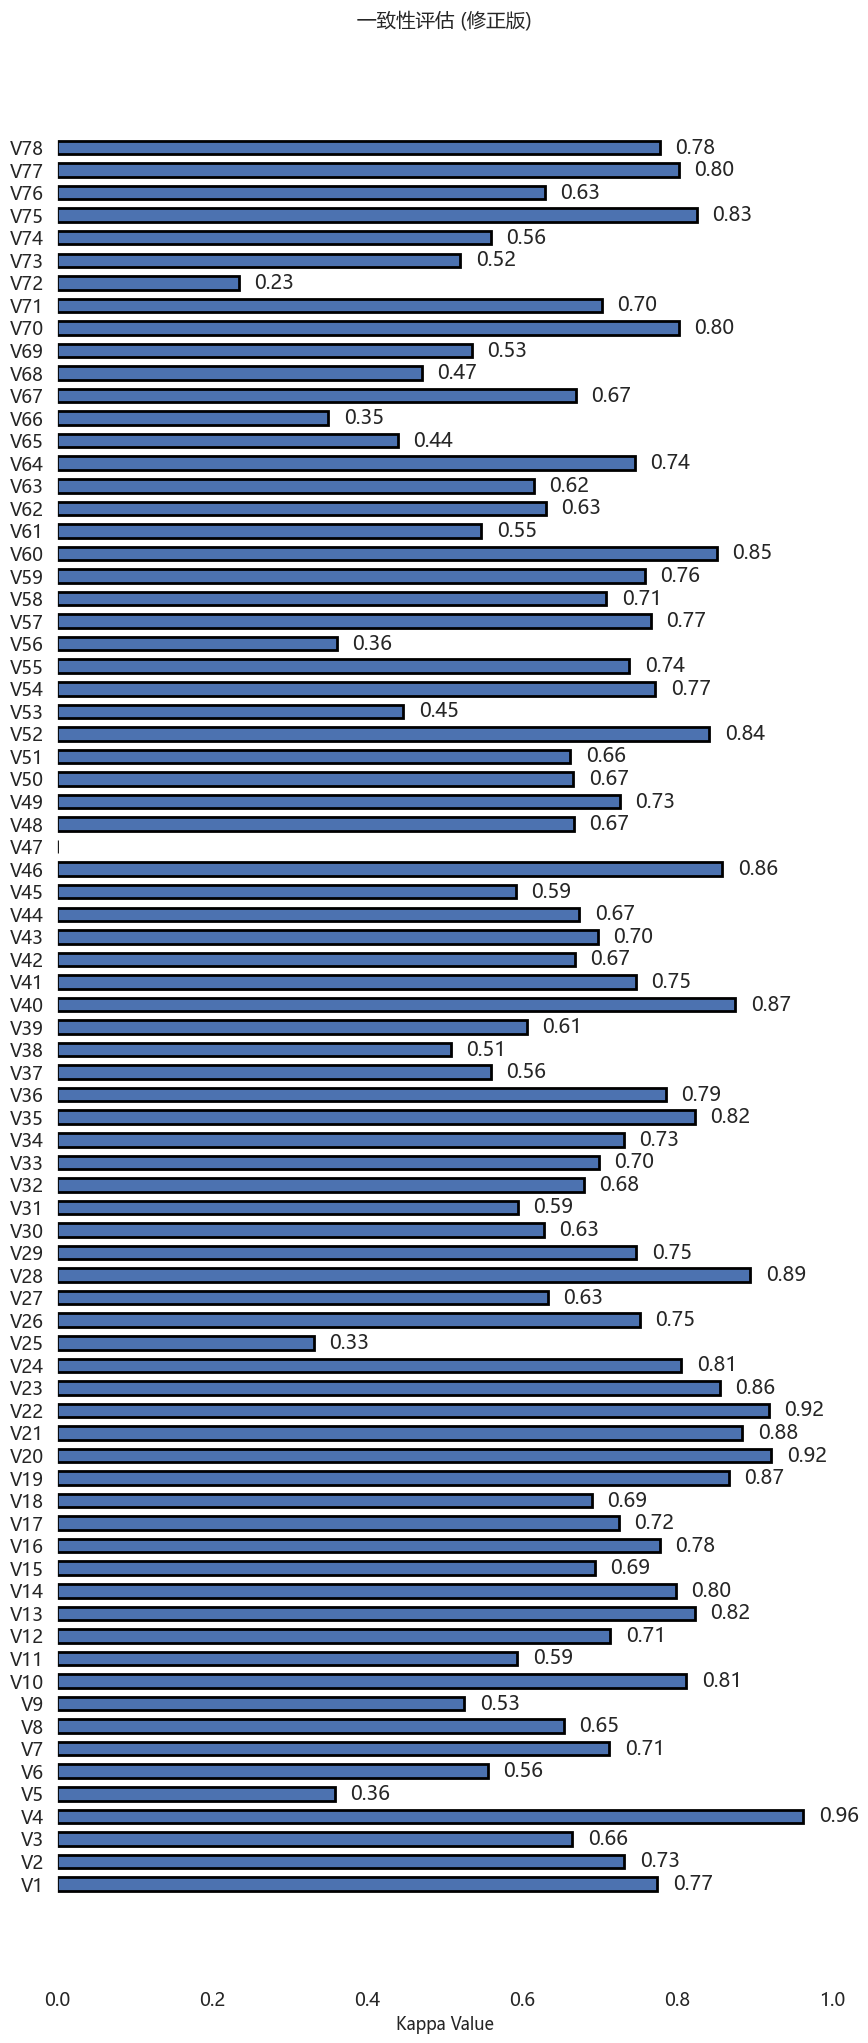

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams['font.sans-serif'] = ['Microsoft YaHei', 'SimHei', 'Arial Unicode MS']  
# 解决负号显示异常
plt.rcParams['axes.unicode_minus'] = False  
# 读取数据
kappa_df = pd.read_csv(r'D:\project\Coloseg\video_kappa_results.csv')

# 数据处理：负数归零
kappa_values = kappa_df['Kappa'].clip(lower=0)  # 网页14的负数处理思路

# 创建水平条形图（交换坐标轴）
plt.figure(figsize=(10, 25))
bars = plt.barh(
    y=range(len(kappa_df)), 
    width=kappa_values,
    height=0.6,  # 加粗条形（网页2的barh参数）
    edgecolor='black',  # 边框颜色（网页11的样式设置）
    linewidth=2,  # 边框宽度
)

# 设置背景透明
plt.gca().set_facecolor('none')  # 坐标区域透明（网页6）
plt.gcf().set_facecolor('none')  # 整个画布透明（网页6）

# 设置坐标轴标签
plt.yticks(ticks=range(len(kappa_df)), 
          labels=[f'V{i+1}' for i in range(len(kappa_df))])  # 自定义Y轴标签
plt.xlabel("Kappa Value", fontsize=12)
plt.title('一致性评估 (修正版)', pad=20, fontsize=14)

# 增强可视性设置
plt.grid(axis='x', linestyle=':', alpha=0.5)  # 横向虚线网格（网页5）
plt.xlim(0, 1)  # 固定X轴范围（网页10）

# 添加数据标签
for bar in bars:
    width = bar.get_width()
    if width > 0:  # 仅显示正值标签
        plt.text(width + 0.02, 
                bar.get_y() + bar.get_height()/2,
                f'{width:.2f}',
                va='center')

# plt.tight_layout()
# plt.savefig('kappa_chart.jpg', dpi=300, transparent=True)
plt.show()